# Leader Effects Results Processing

This notebook is the dedicated results-processing entry for the current thesis experiments. It loads the completed `leader_effects_main` run together with the `no_leader_control` run, checks alignment, and then produces the paper-facing plots and comparison tables.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from visualization import (
    build_leader_control_comparison_summary,
    build_leader_control_comparison_table,
    load_leader_effects_bundle,
    plot_leader_control_content_balance,
    plot_leader_control_extremism,
    plot_leader_control_mean_opinion,
    plot_leader_effects_content_balance,
    plot_leader_effects_extremism,
    plot_leader_effects_heatmap,
    plot_leader_effects_mode_comparison,
    plot_leader_effects_overview,
    plot_no_leader_control_content,
    plot_no_leader_control_extremism,
    plot_no_leader_control_mean_opinion,
    summarize_leader_control_alignment,
)


In [2]:
MAIN_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'leader_effects_main'
CONTROL_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'leader_effects_no_leader_control'
BENCHMARK_SHARE = 0.03

bundle = load_leader_effects_bundle(MAIN_OUTPUT_DIR, CONTROL_OUTPUT_DIR)
main_outputs = bundle['main']
control_outputs = bundle['control']

main_summary_df = main_outputs['summary_df']
main_raw_df = main_outputs['raw_df']
control_summary_df = control_outputs['summary_df']
control_raw_df = control_outputs['raw_df']

alignment_summary = summarize_leader_control_alignment(main_raw_df, control_raw_df)
comparison_summary_df = build_leader_control_comparison_summary(
    main_summary_df,
    control_summary_df,
    benchmark_share=BENCHMARK_SHARE,
)
comparison_table_df = build_leader_control_comparison_table(comparison_summary_df)

display(main_outputs['manifest'])
display(control_outputs['manifest'])
display(alignment_summary)


{'created_at_utc': '2026-04-19T09:29:11.137898+00:00',
 'profile_name': 'main',
 'profile_description': 'Core thesis-ready matrix on the tuned simple leader influence baseline.',
 'scenario_name': 'core',
 'scenario_description': 'Main paper matrix over population size, topology, leader mode, and leader share.',
 'output_dir': 'outputs\\leader_effects_main',
 'condition_count': 648,
 'completed_run_count': 648,
 'population_sizes': [500, 1000, 1500],
 'topologies': ['BA', 'ER', 'SBM', 'WS'],
 'leader_modes': ['balanced', 'negative', 'positive'],
 'leader_shares': [0.01, 0.03, 0.05],
 'rounds': [50],
 'seeds': [42, 59, 76, 93, 110, 127],
 'leader_rule': 'Exogenous leader share, then select top-k nodes by realized in-degree rank.',
 'fixed_parameter_base': 'simple leader influence baseline',
 'default_main_rounds': 50,
 'trial_rounds': 25,
 'notes': None}

{'created_at_utc': '2026-04-20T01:35:07.745150+00:00',
 'profile_name': 'main',
 'profile_description': 'Core thesis-ready matrix on the tuned simple leader influence baseline.',
 'scenario_name': 'no_leader_control',
 'scenario_description': 'Control experiment with no opinion leaders and all other tuned parameters held fixed.',
 'output_dir': 'outputs/leader_effects_no_leader_control',
 'condition_count': 72,
 'completed_run_count': 72,
 'population_sizes': [500, 1000, 1500],
 'topologies': ['BA', 'ER', 'SBM', 'WS'],
 'leader_modes': ['none'],
 'leader_shares': [0.0],
 'rounds': [50],
 'seeds': [42, 59, 76, 93, 110, 127],
 'leader_rule': "No opinion leaders: leader_share=0 and leader_selection_method='none'.",
 'fixed_parameter_base': 'simple leader influence baseline',
 'default_main_rounds': 50,
 'trial_rounds': 25,
 'notes': None}

{'main_condition_count': 648,
 'control_condition_count': 72,
 'main_seed_count': 6,
 'control_seed_count': 6,
 'shared_population_sizes': [500, 1000, 1500],
 'shared_topologies': ['BA', 'ER', 'SBM', 'WS'],
 'shared_rounds': [50],
 'grid_alignment_ok': True}

In [3]:
display(main_summary_df.head())
display(control_summary_df.head())
display(comparison_table_df.head(12))


,profile_name,scenario_name,N,topology,leader_share,leader_mode,leader_selection_method,T_rounds,final_mean_opinion_mean,final_mean_opinion_std,...,actual_creators_total_sem,actual_creators_total_ci_low,actual_creators_total_ci_high,actual_creators_total_n,avg_exposure_size_mean_mean,avg_exposure_size_mean_std,avg_exposure_size_mean_sem,avg_exposure_size_mean_ci_low,avg_exposure_size_mean_ci_high,avg_exposure_size_mean_n
0,main,core,500,BA,0.01,balanced,top_in_degree,50,-0.064157,0.252566,...,76.923338,2029.230257,2330.769743,6,2.729713,0.202430,0.082642,2.567735,2.891691,6
1,main,core,500,BA,0.01,negative,top_in_degree,50,-0.331713,0.058824,...,27.231620,2381.792692,2488.540641,6,3.030700,0.133360,0.054444,2.923989,3.137411,6
2,main,core,500,BA,0.01,positive,top_in_degree,50,0.240489,0.045422,...,38.928710,2241.033062,2393.633604,6,2.834960,0.149926,0.061207,2.714994,2.954926,6
3,main,core,500,BA,0.03,balanced,top_in_degree,50,-0.153350,0.353686,...,113.911491,1745.900144,2192.433189,6,4.028667,0.464887,0.189789,3.656679,4.400654,6
4,main,core,500,BA,0.03,negative,top_in_degree,50,-0.541623,0.052946,...,14.634814,3100.649098,3158.017569,6,5.617387,0.098676,0.040284,5.538430,5.696344,6


,profile_name,scenario_name,N,topology,leader_share,leader_mode,leader_selection_method,T_rounds,final_mean_opinion_mean,final_mean_opinion_std,...,actual_creators_total_sem,actual_creators_total_ci_low,actual_creators_total_ci_high,actual_creators_total_n,avg_exposure_size_mean_mean,avg_exposure_size_mean_std,avg_exposure_size_mean_sem,avg_exposure_size_mean_ci_low,avg_exposure_size_mean_ci_high,avg_exposure_size_mean_n
0,main,no_leader_control,500,BA,0.0,none,none,50,-0.032787,0.055520,...,9.217435,1900.100494,1936.232840,6,1.679847,0.023908,0.009760,1.660716,1.698977,6
1,main,no_leader_control,500,ER,0.0,none,none,50,-0.032386,0.063431,...,14.752778,1936.751223,1994.582111,6,1.716287,0.036746,0.015002,1.686883,1.745690,6
2,main,no_leader_control,500,SBM,0.0,none,none,50,-0.021132,0.075166,...,22.535897,1871.829641,1960.170359,6,1.675793,0.049842,0.020348,1.635911,1.715676,6
3,main,no_leader_control,500,WS,0.0,none,none,50,-0.021239,0.083340,...,17.414075,1932.368413,2000.631587,6,1.719527,0.038864,0.015866,1.688429,1.750624,6
4,main,no_leader_control,1000,BA,0.0,none,none,50,0.033155,0.173316,...,62.958937,3522.433816,3769.232850,6,3.118980,0.131423,0.053653,3.013819,3.224141,6


,N,topology,comparison_group,final_mean_opinion_mean,final_mean_opinion_ci_low,final_mean_opinion_ci_high,content_balance_mean,content_balance_ci_low,content_balance_ci_high,extremist_ratio_mean,extremist_ratio_ci_low,extremist_ratio_ci_high,homophily_ratio_mean
0,500,BA,no leader,-0.032787,-0.077212,0.011639,-45.166667,-152.575640,62.242307,0.230667,0.211102,0.250232,0.561866
1,500,BA,balanced (3%),-0.153350,-0.436358,0.129658,-162.833333,-605.424138,279.757471,0.530333,0.472655,0.588011,0.628182
2,500,BA,positive (3%),0.481146,0.431901,0.530392,1683.833333,1531.518576,1836.148090,0.535667,0.495024,0.576309,0.880537
3,500,BA,negative (3%),-0.541623,-0.583988,-0.499257,-1918.000000,-2018.732051,-1817.267949,0.568333,0.533062,0.603605,0.898318
4,500,ER,no leader,-0.032386,-0.083142,0.018369,-32.666667,-151.714327,86.380993,0.227667,0.211554,0.243779,0.579770
5,500,ER,balanced (3%),-0.042165,-0.252972,0.168642,-41.833333,-348.354364,264.687697,0.459667,0.414375,0.504958,0.606707
6,500,ER,positive (3%),0.432293,0.377345,0.487242,1452.166667,1286.523731,1617.809603,0.503333,0.465090,0.541577,0.867014
7,500,ER,negative (3%),-0.498843,-0.553885,-0.443801,-1631.000000,-1792.913084,-1469.086916,0.523333,0.471342,0.575325,0.886580
8,500,SBM,no leader,-0.021132,-0.081277,0.039013,-15.666667,-188.251811,156.918478,0.231000,0.215592,0.246408,0.591966
9,500,SBM,balanced (3%),-0.178217,-0.455180,0.098746,-302.000000,-677.741423,73.741423,0.519667,0.477454,0.561879,0.651984


## Main Experiment Figures

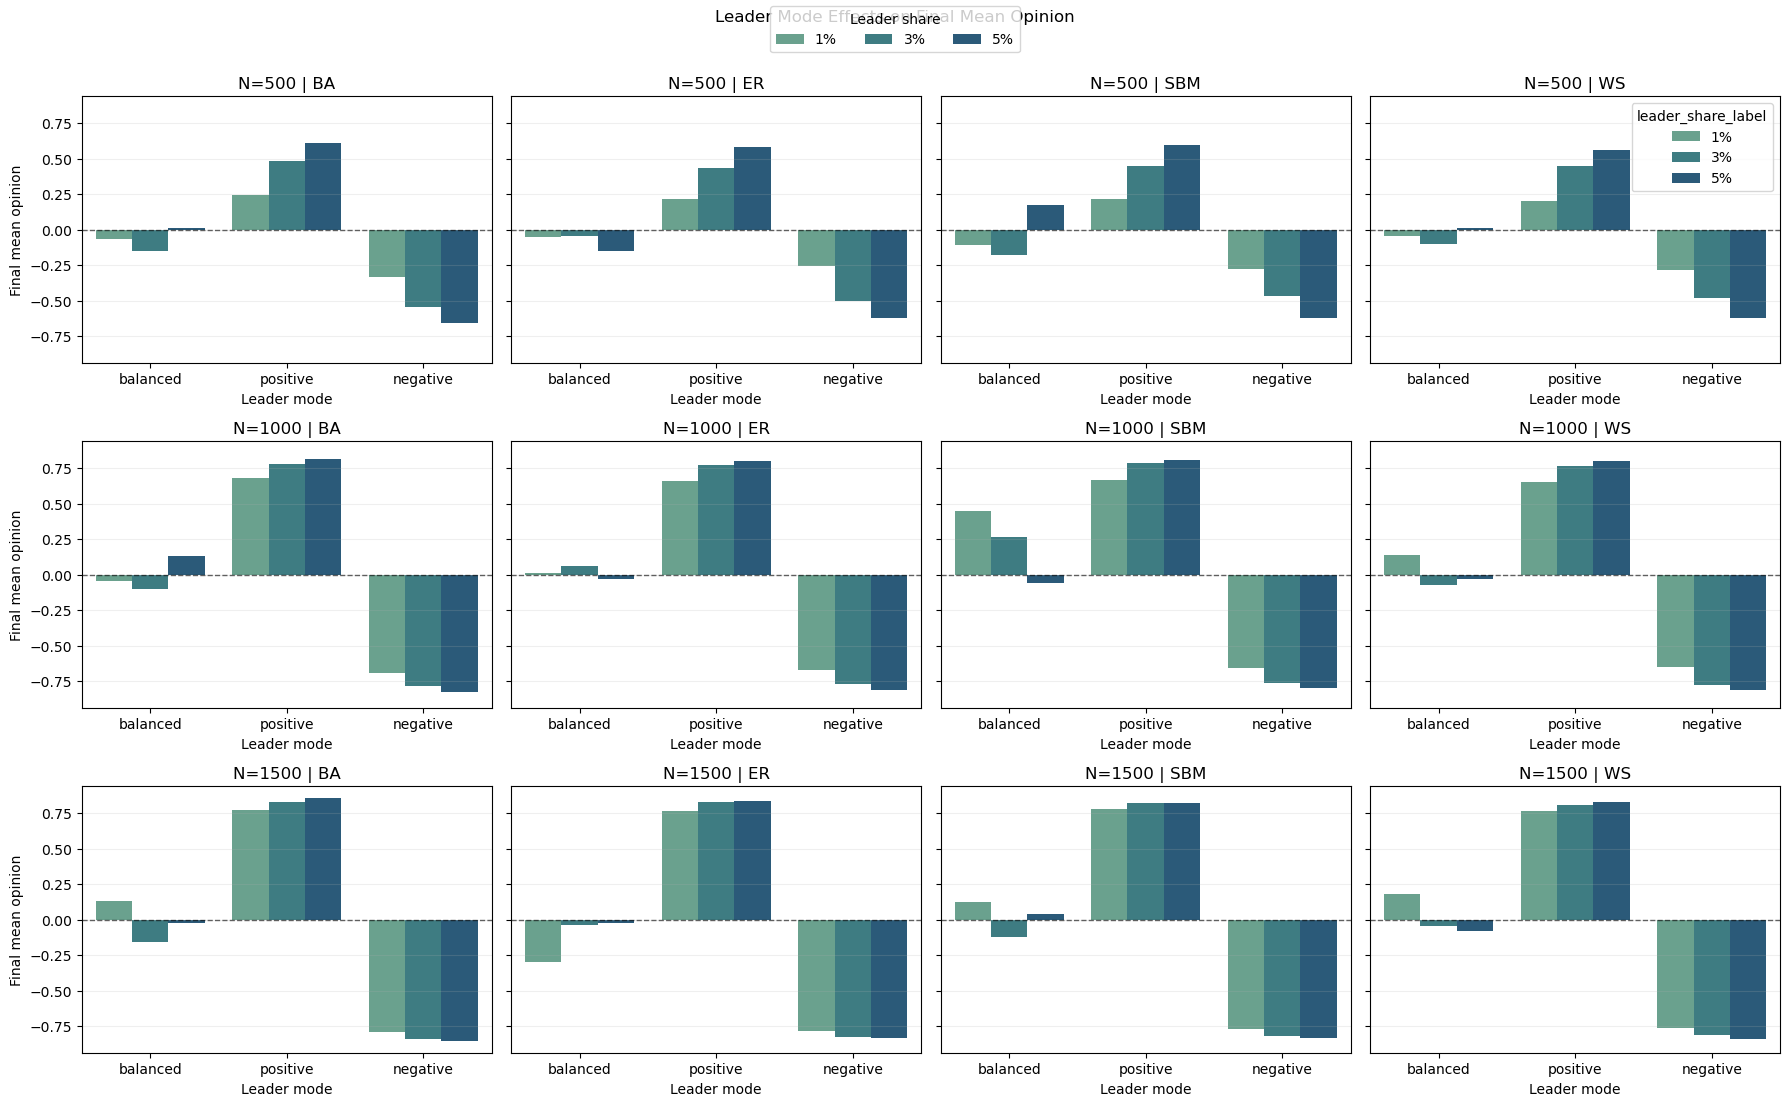

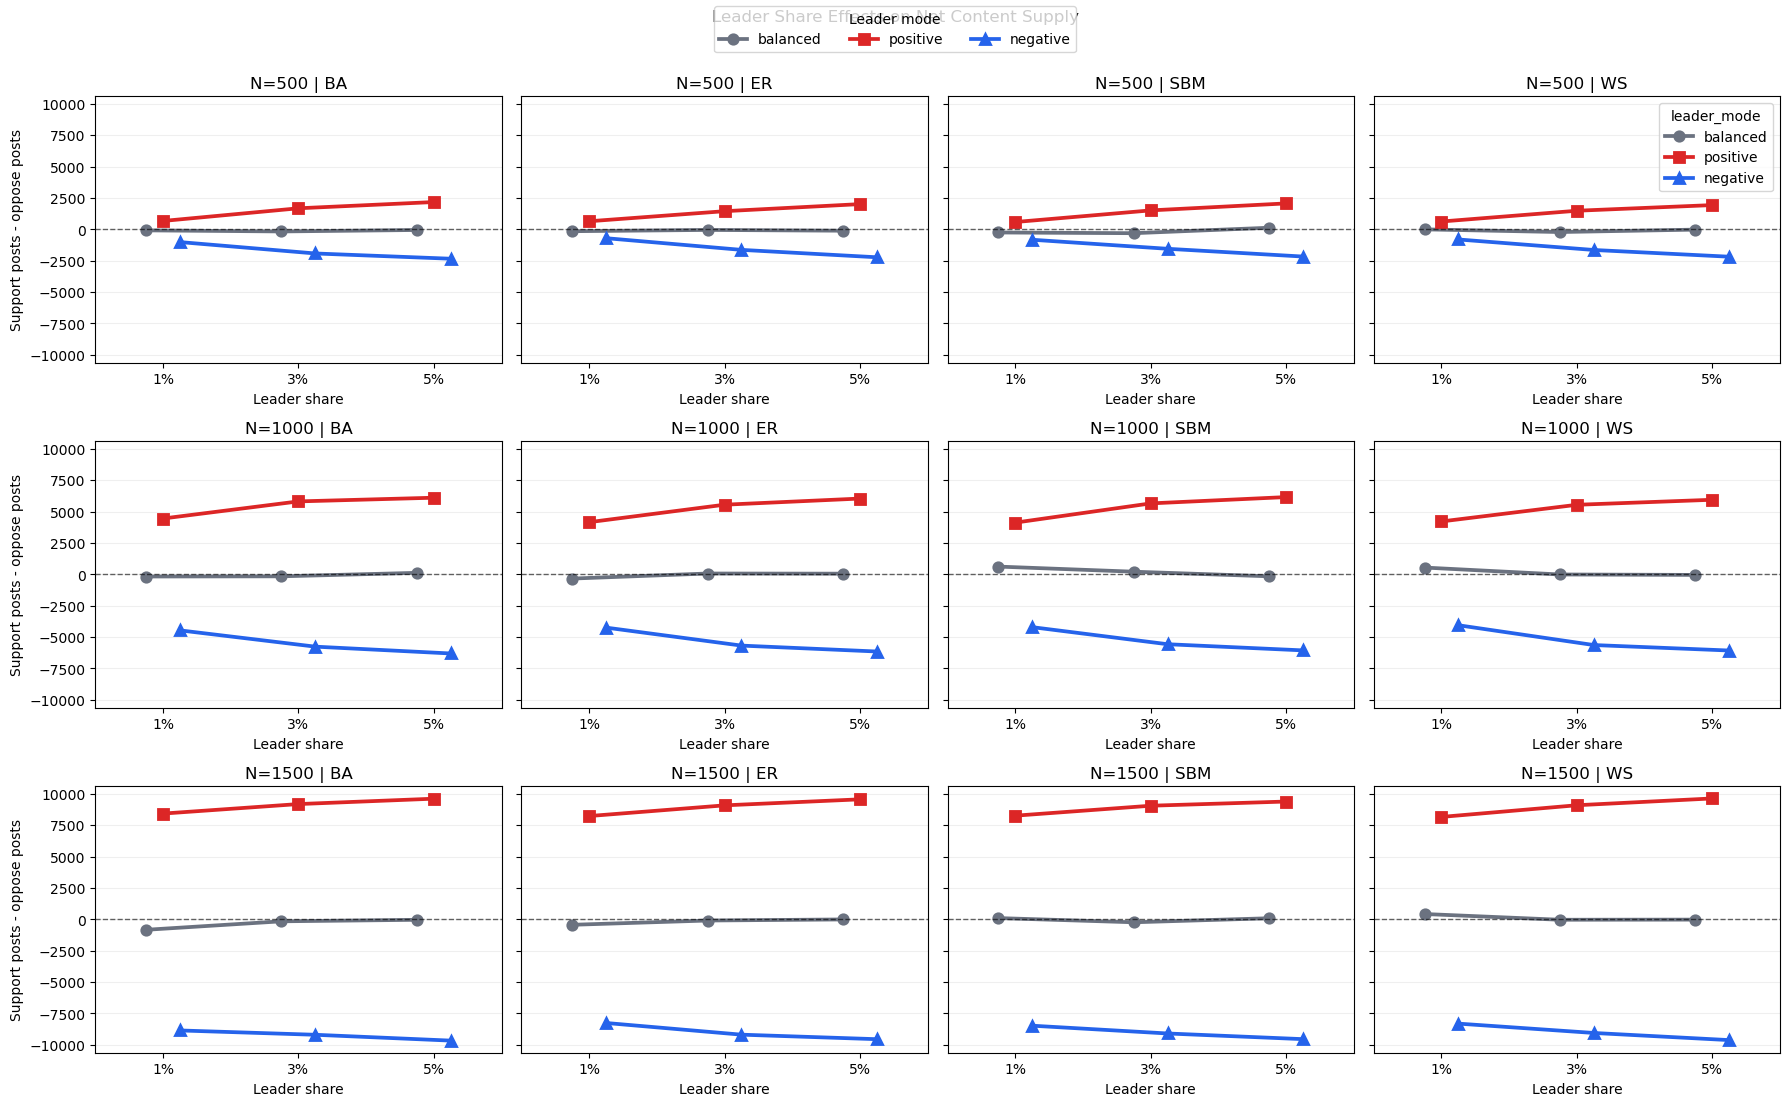

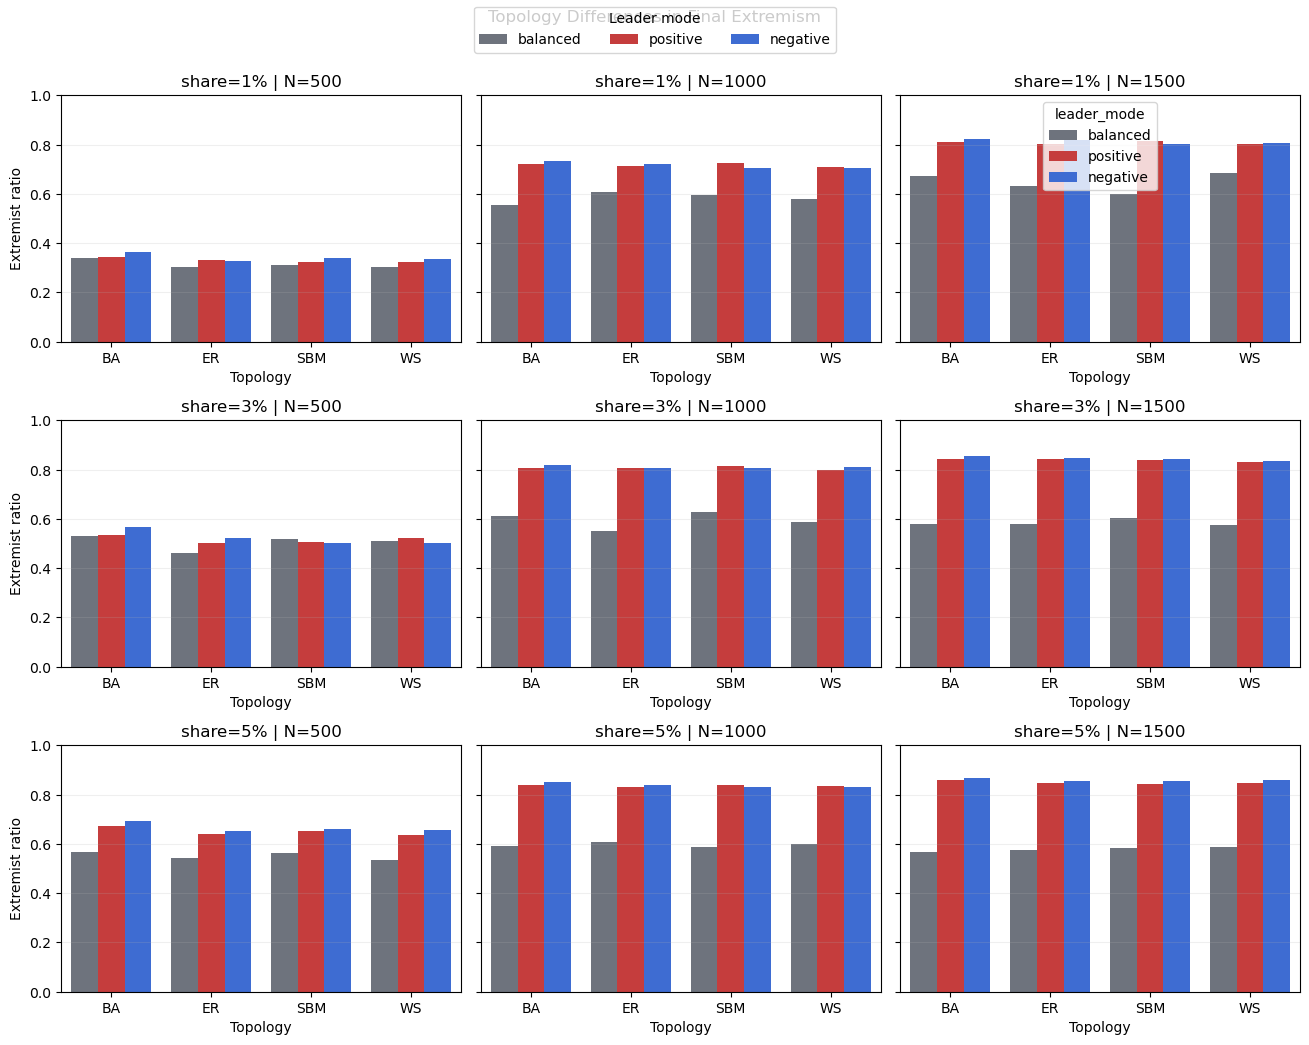

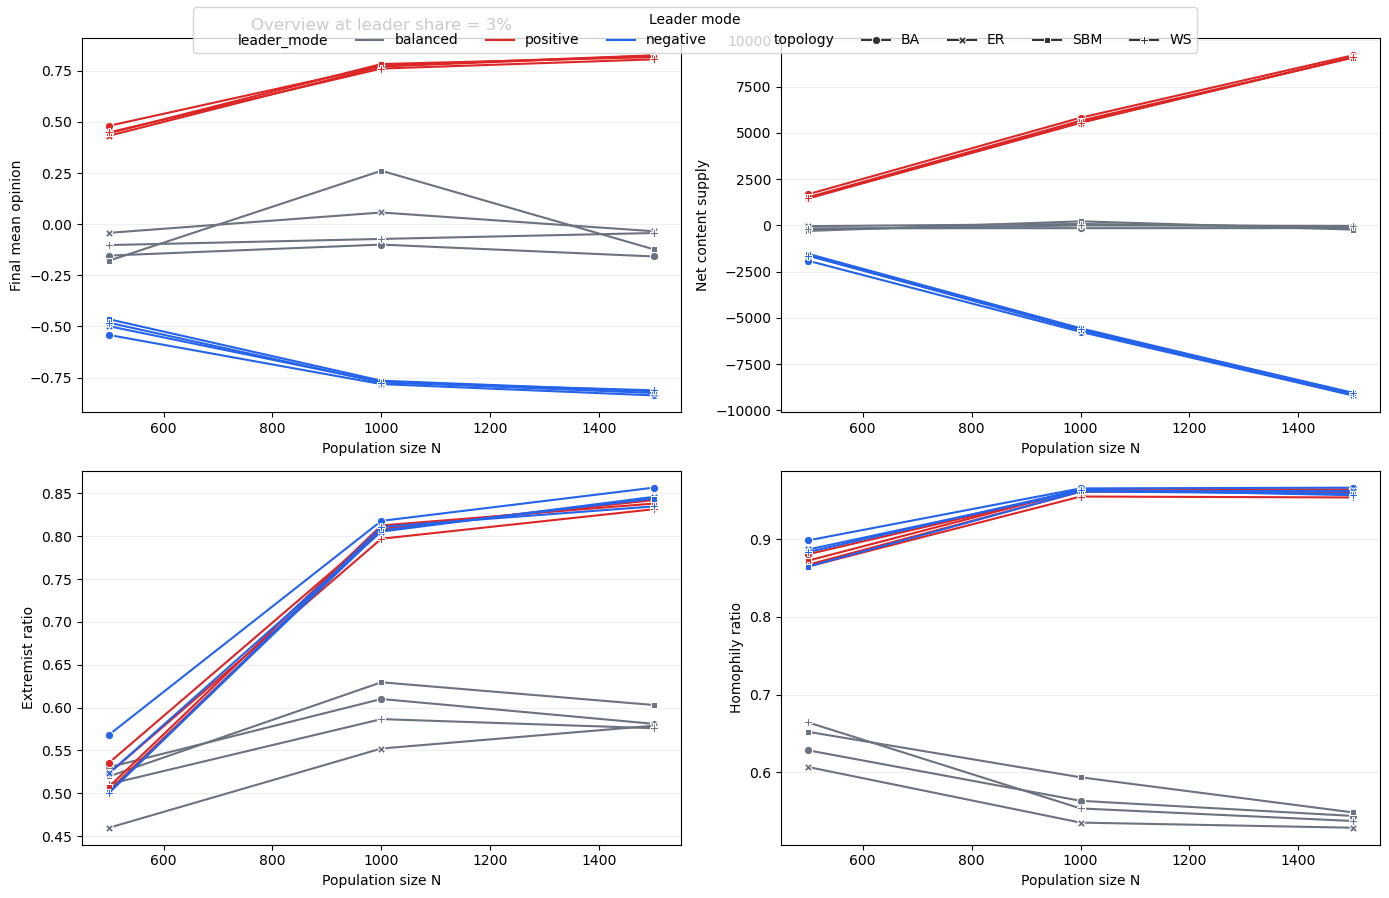

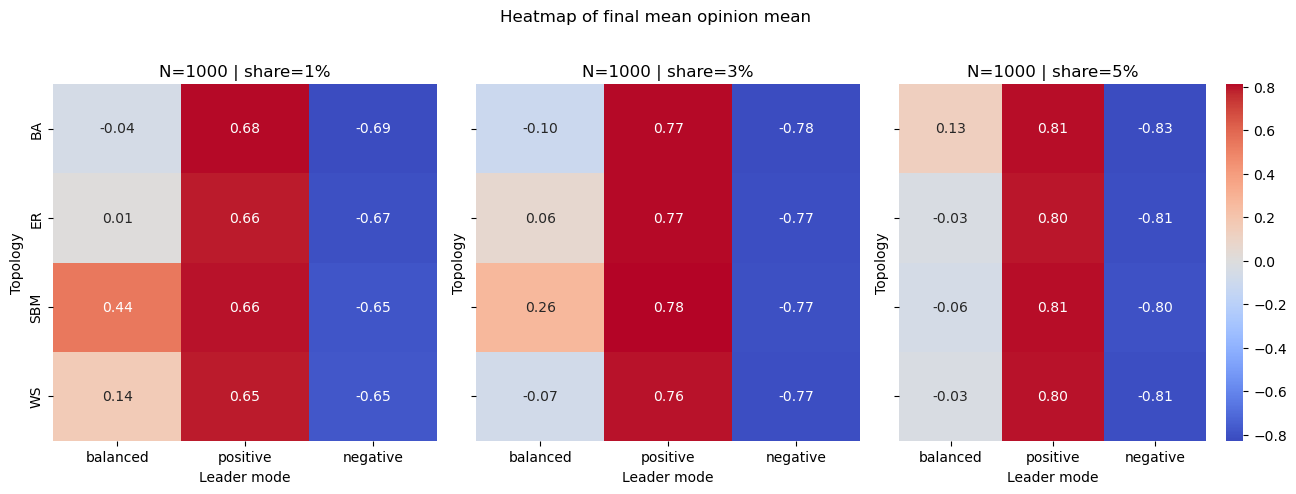

In [4]:
fig, _ = plot_leader_effects_mode_comparison(main_summary_df)
plt.show()

fig, _ = plot_leader_effects_content_balance(main_summary_df)
plt.show()

fig, _ = plot_leader_effects_extremism(main_summary_df)
plt.show()

fig, _ = plot_leader_effects_overview(main_summary_df)
plt.show()

fig, _ = plot_leader_effects_heatmap(main_summary_df, metric='final_mean_opinion_mean', fixed_n=1000)
plt.show()


## No-Leader Control Figures

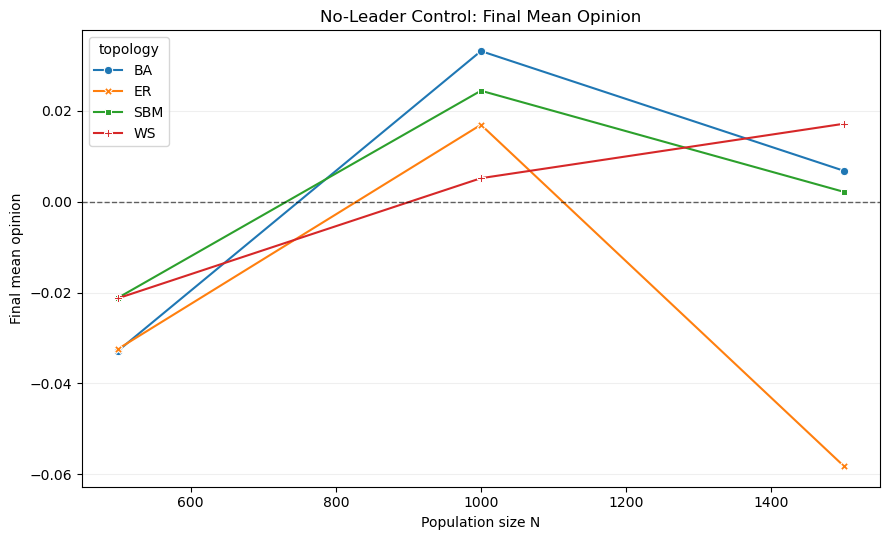

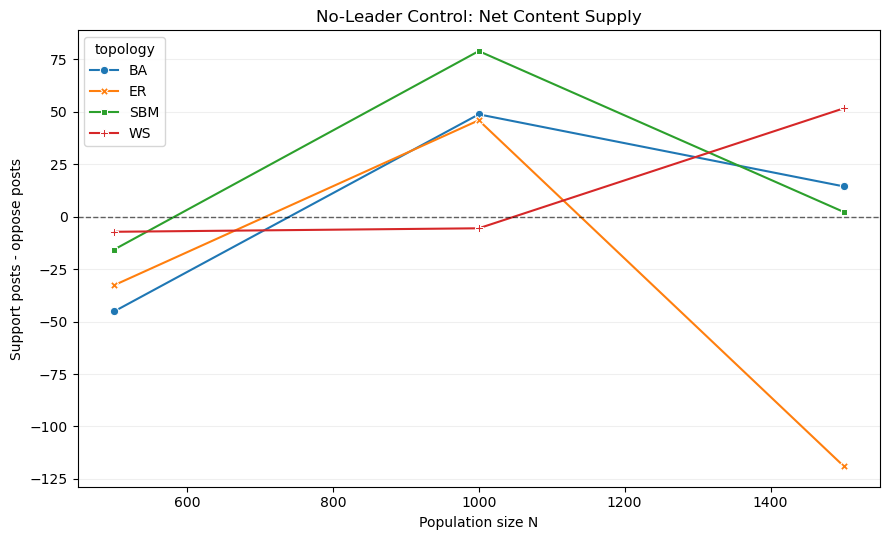

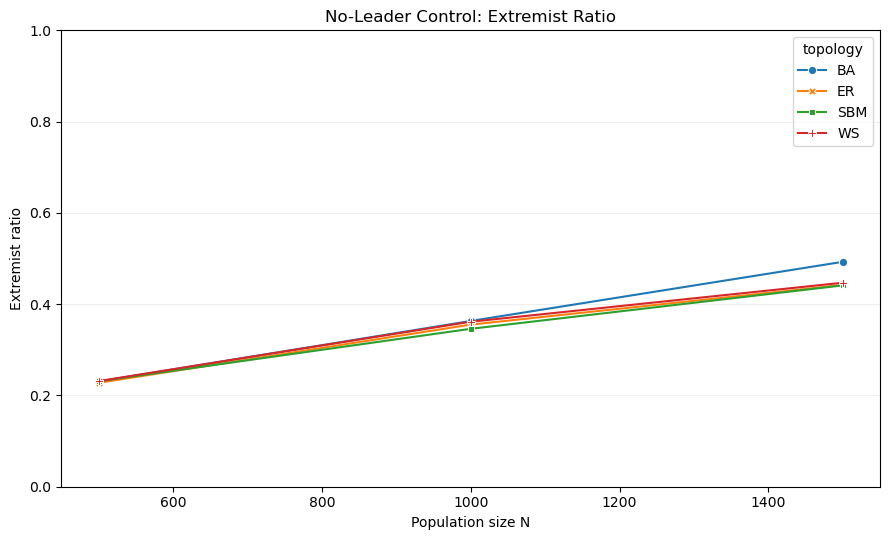

In [5]:
fig, _ = plot_no_leader_control_mean_opinion(control_summary_df)
plt.show()

fig, _ = plot_no_leader_control_content(control_summary_df)
plt.show()

fig, _ = plot_no_leader_control_extremism(control_summary_df)
plt.show()


## Consistent Stitching: No Leader vs 3% Leader Benchmark

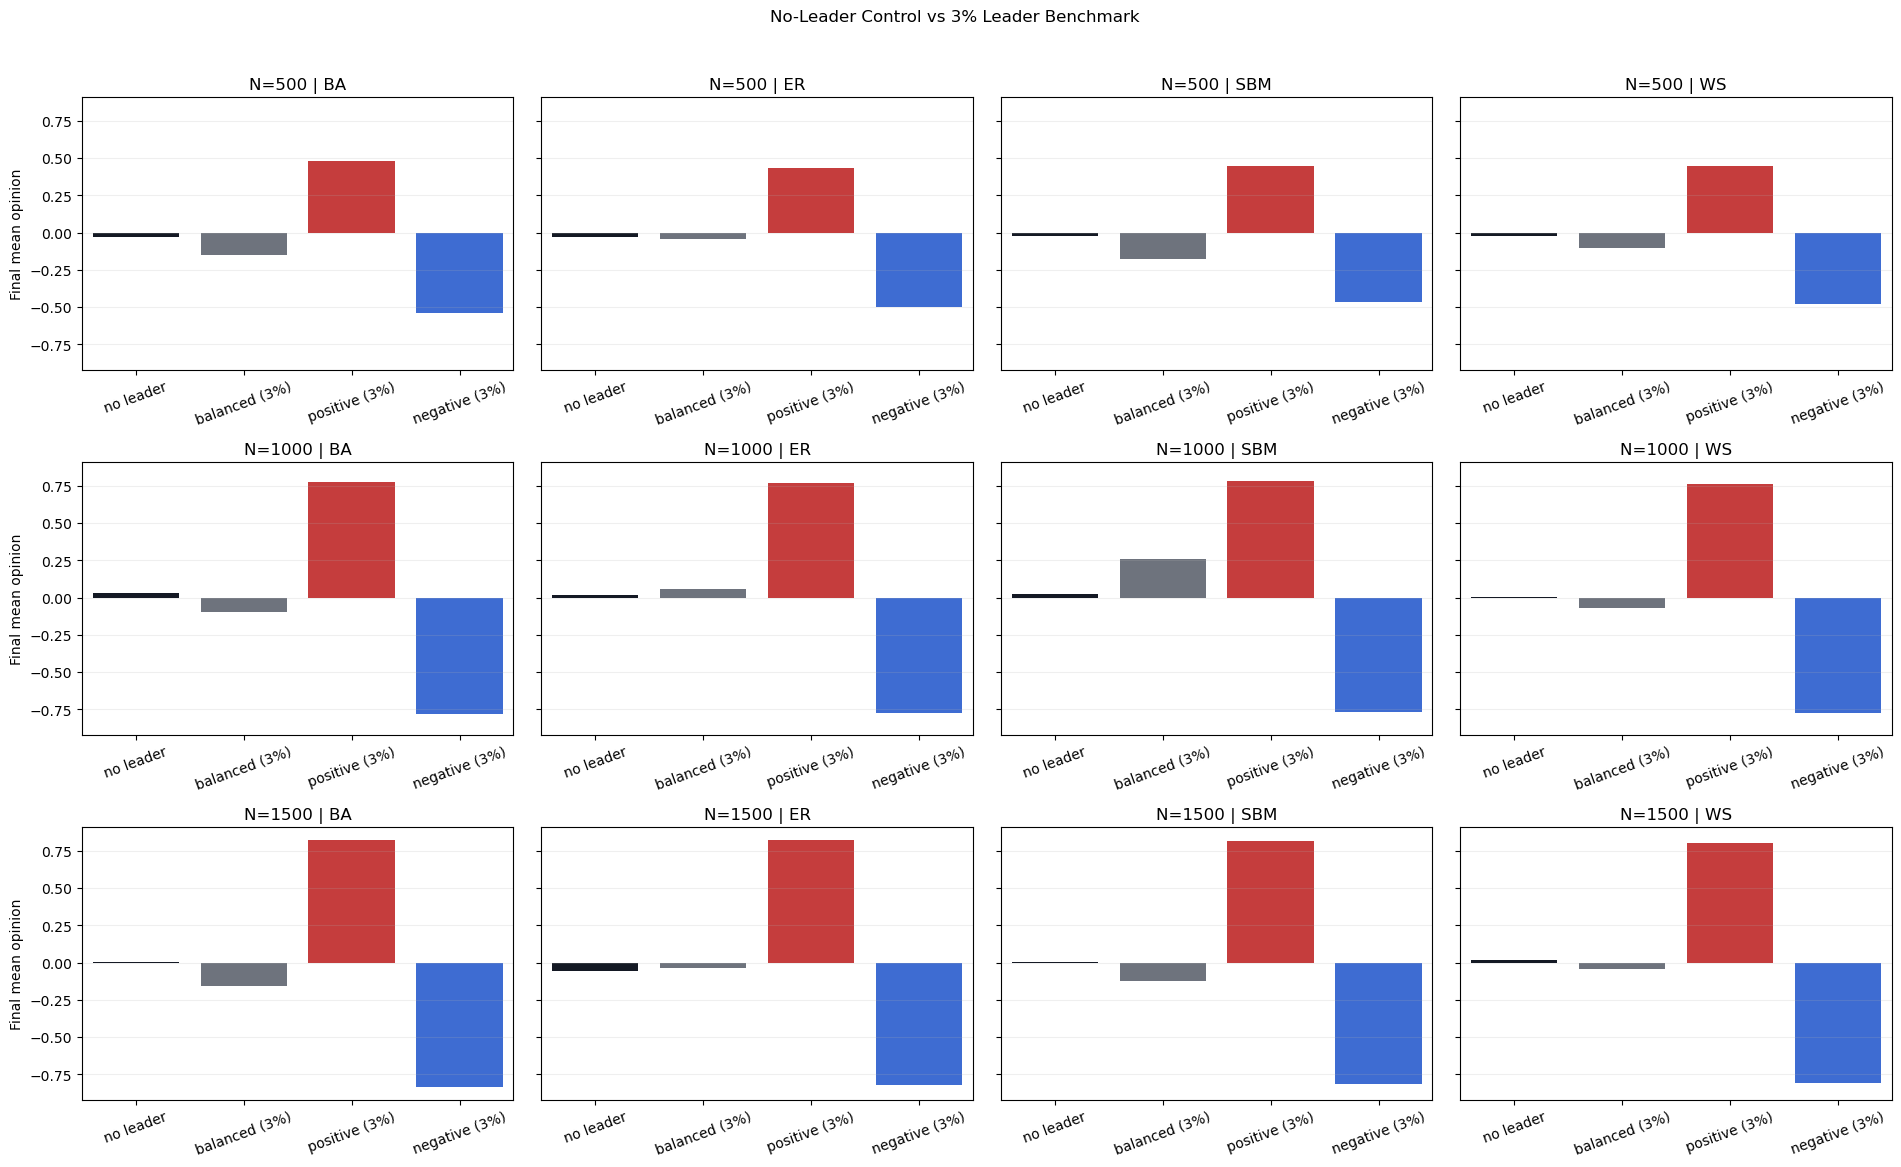

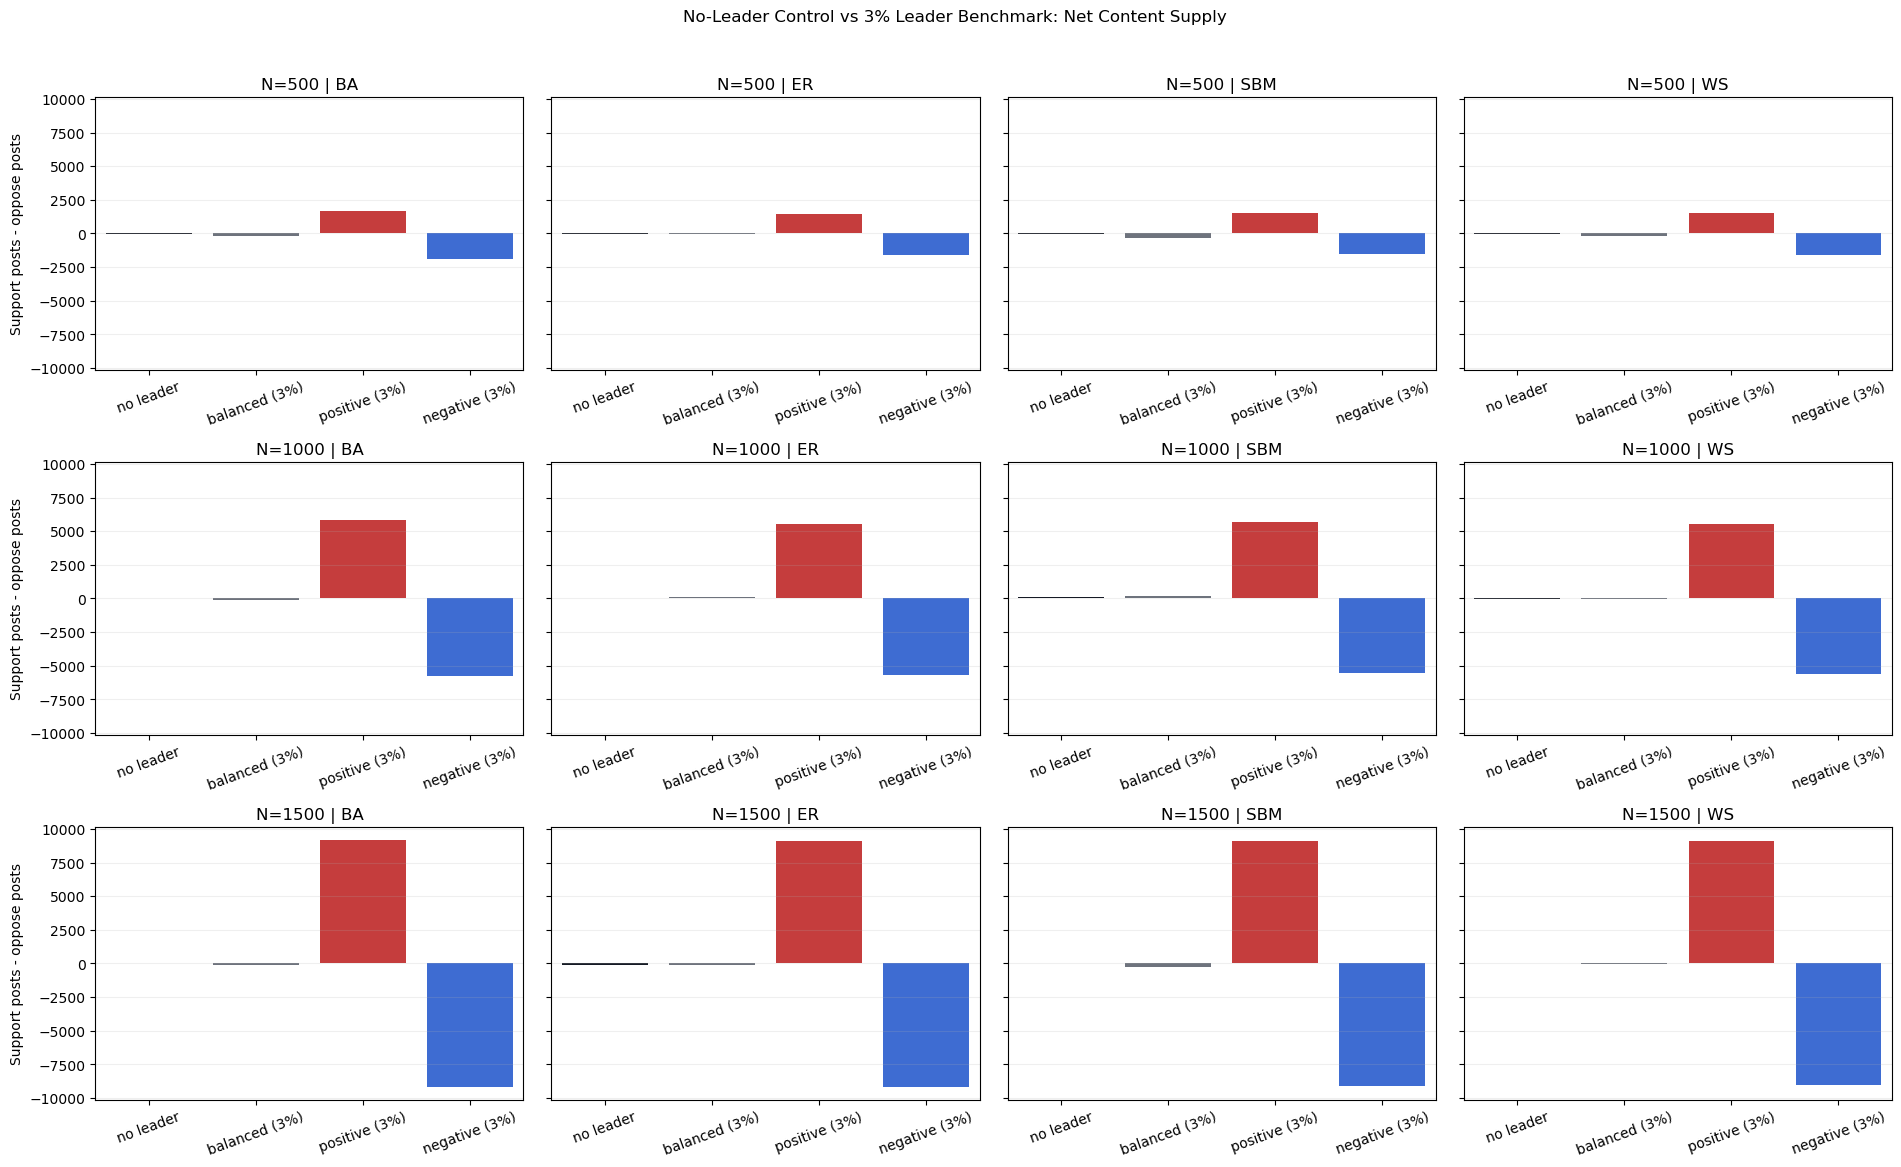

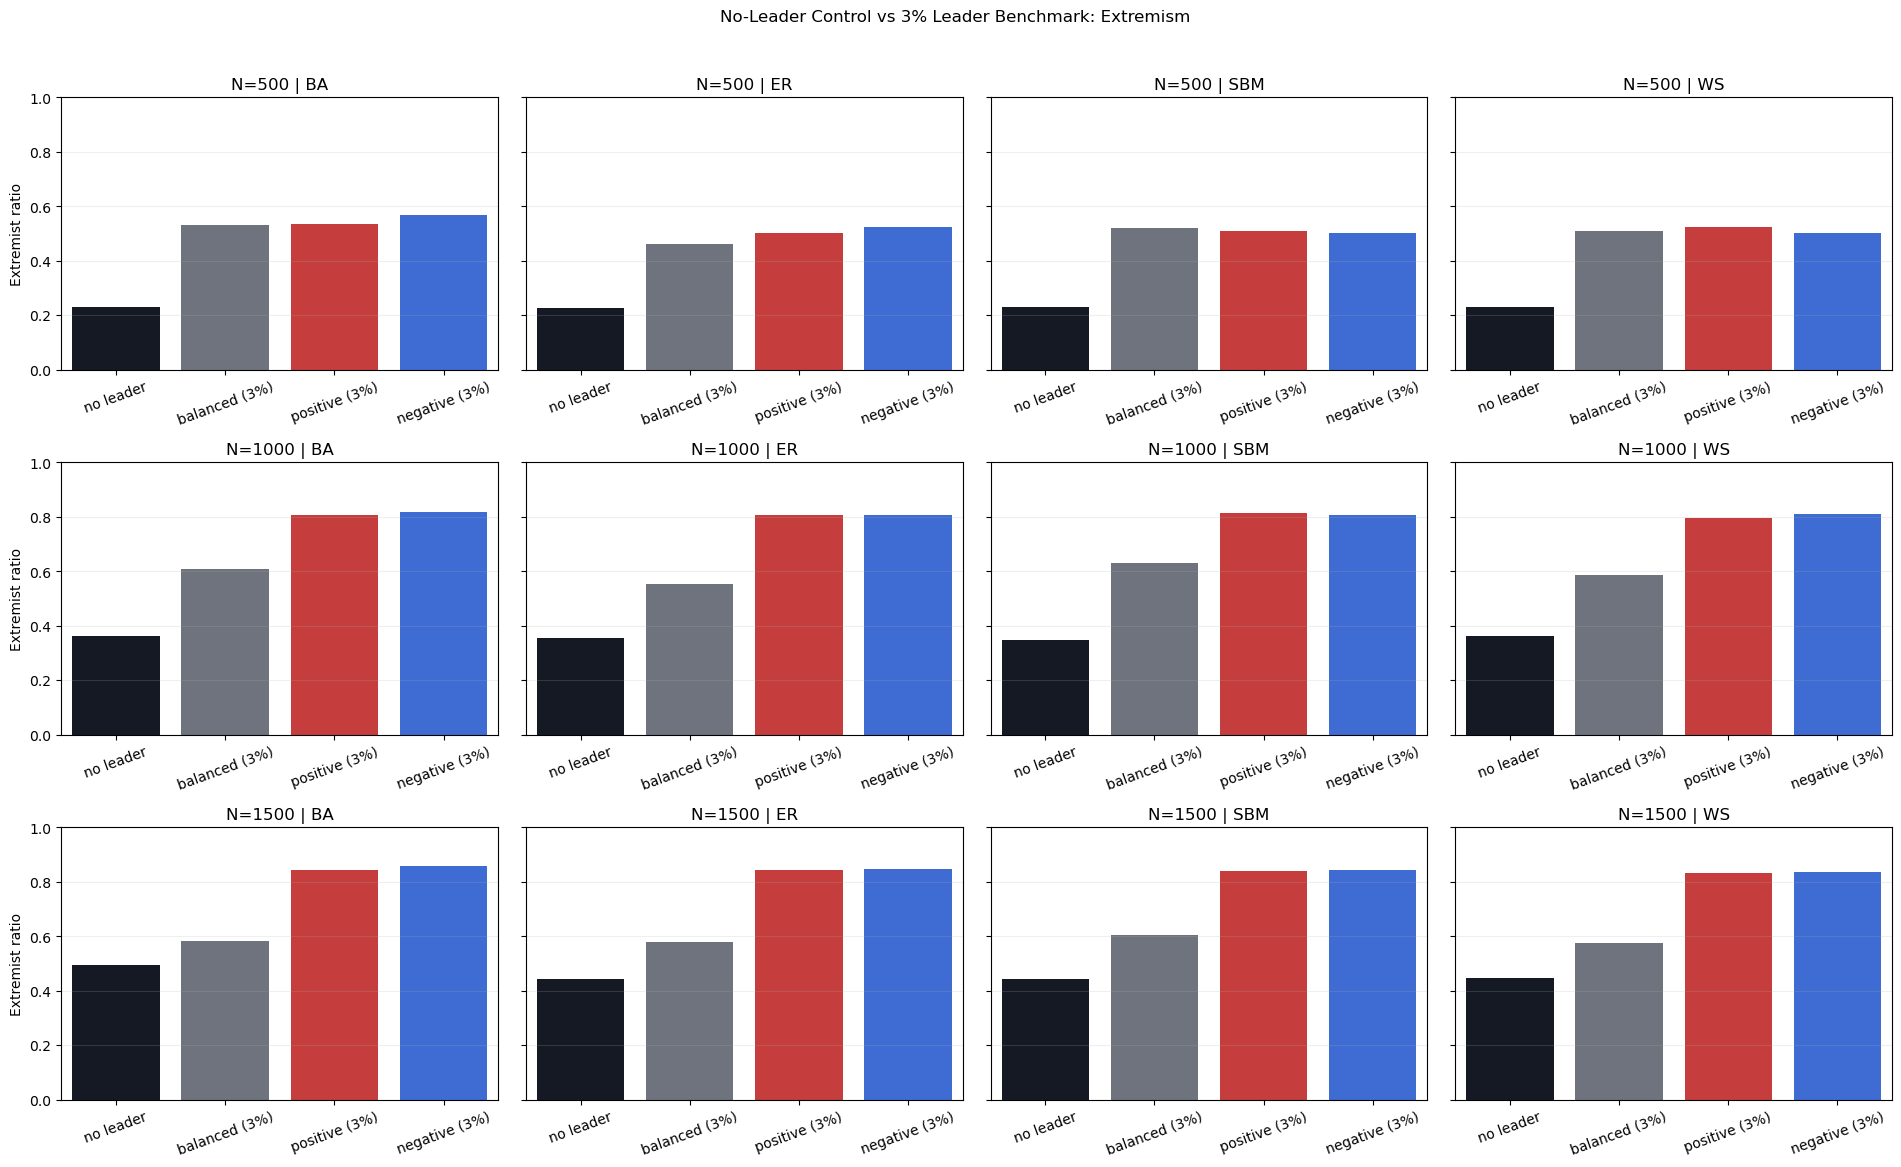

In [6]:
fig, _ = plot_leader_control_mean_opinion(comparison_summary_df)
plt.show()

fig, _ = plot_leader_control_content_balance(comparison_summary_df)
plt.show()

fig, _ = plot_leader_control_extremism(comparison_summary_df)
plt.show()


In [8]:
EXPORT_COMPARISON_TABLE = True

if EXPORT_COMPARISON_TABLE:
    export_path = PROJECT_ROOT / 'outputs' / 'leader_effects_no_leader_control' / 'tables' / 'no_leader_vs_3pct_benchmark.csv'
    comparison_table_df.to_csv(export_path, index=False)
    print(export_path)
else:
    print('Set EXPORT_COMPARISON_TABLE = True to save the stitched comparison table.')


D:\ProgramScripts\Opinion_ABM\outputs\leader_effects_no_leader_control\tables\no_leader_vs_3pct_benchmark.csv
